<a href="https://colab.research.google.com/github/christinengalle19-collab/Assignement2New/blob/main/Assignment6ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
# Add your imports here:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# --- Data Collection and Loading ---
# TODO: Load the 'California Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Hint: Use `fetch_california_housing()` from `sklearn.datasets`

# Load dataset and convert to DataFrame:


# Add your code here:
california_housing = fetch_california_housing(as_frame=True)
df = california_housing.frame

In [3]:
# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
# Hint: Use `.head()` to inspect the first few rows.

# Add your code here:

print(df.head())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [4]:
# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
# Hint: Use `.info()` and `.describe()` to inspect data types and statistical properties.

# Add your code here:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.

In [7]:
# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
# Hint: Use `.isnull().sum()` to check for null values.

# Add your code here:
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


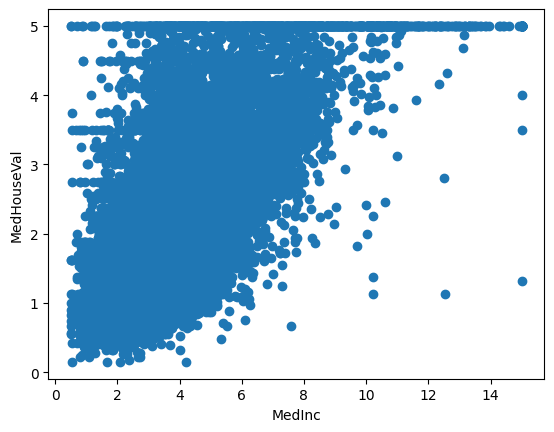

In [8]:
# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable (MedHouseVal).
# Example: Use `plt.scatter()` to visualize the relationship between 'MedInc' and 'MedHouseVal'.

# Add your code here:
plt.scatter(df['MedInc'], df['MedHouseVal'])
plt.xlabel('MedInc')
plt.ylabel('MedHouseVal')
plt.show()

#The analysis reveals a strong positive linear association between median income (by block) and median housing value (by group). This implies that increases in income levels are consistently associated with higher housing values across the dataset.

In [10]:
# TODO: Create a function to automate scatter plots for all features vs MedHouseVal.
# Hint: The function should loop over a list of features and plot scatter plots for each.

# Define your function here:
def scatter_plot(df, features):
    for feature in features:
        plt.scatter(df[feature], df['MedHouseVal'])
        plt.xlabel(feature)
        plt.ylabel('MedHouseVal')
        plt.show()

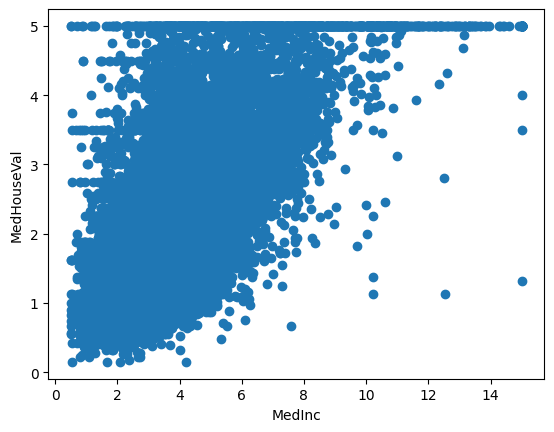

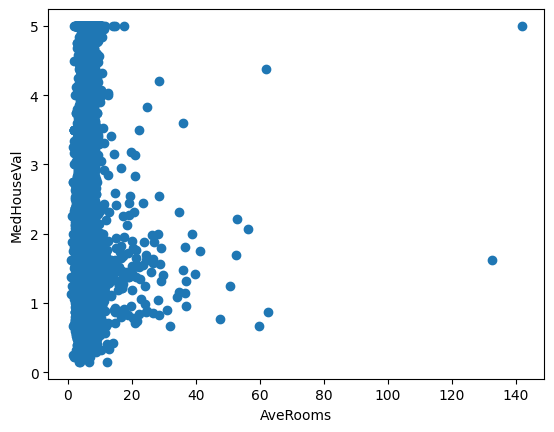

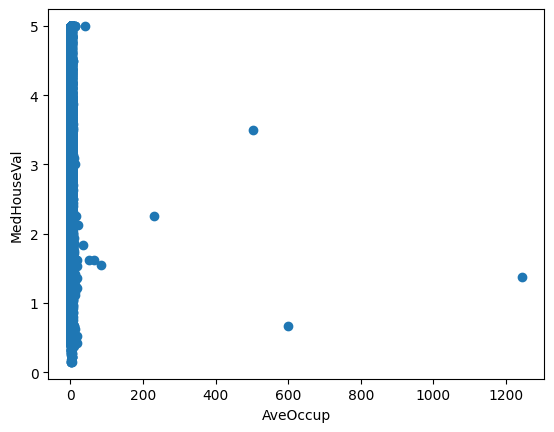

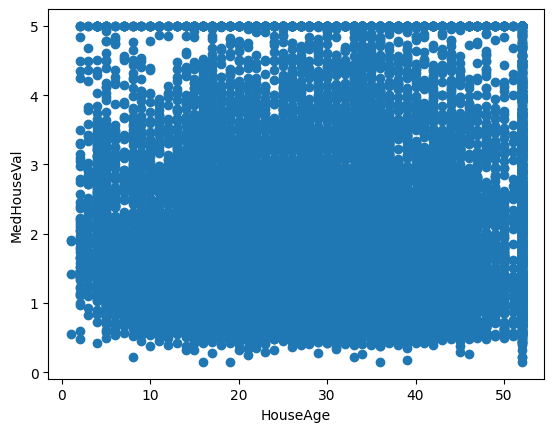

In [11]:
# TODO: Use the function to visualize the relationships between multiple features and the target variable.
# Features: ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
# Target: 'MedHouseVal'

# Add your code here:
features = ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
scatter_plot(df, features)

#The scatter plot analysis shows that median income (MedInc) has the strongest and most consistent positive linear relationship with median housing value, indicating that higher‑income blocks tend to correspond to higher property values. In contrast, the other features AveRooms, AveOccup, and HouseAge display weaker and more diffuse patterns, suggesting limited predictive power. AveRooms shows a mild, non‑linear trend influenced by outliers, AveOccup exhibits almost no meaningful relationship, and HouseAge presents only a weak association. Overall, MedInc stands out as the primary driver of housing value among the selected features.

#

In [ ]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
# Hint: Use `train_test_split()` from `sklearn.model_selection` with an 80/20 split.

# Define X (features) and y (target) and perform the train-test split:

x = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [12]:
# TODO: Choose an appropriate regression model.
# Hint: Use `LinearRegression()` from `sklearn.linear_model`.

# Define your regression model here:
model = LinearRegression()


In [14]:
# TODO: Train the model on the training data.
# Hint: Use `.fit()` to train the model.

# Add your code here:
x = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
fit = model.fit(x_train, y_train)

In [15]:
# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.

# Predict on the test set and calculate the evaluation metrics:

mean_squared_error(y_test, model.predict(x_test))
r2_score(y_test, model.predict(x_test))

0.5757877060324508

#The model help to predict positively because r-score of 0.5757877060324508

The model demonstrates a moderately strong ability to predict the target variable, as reflected by an R‑squared score of 0.576.
This means that approximately 57.6% of the variance in the outcome is explained by the model’s features, indicating a positive and meaningful predictive relationship.
 While the model captures more than half of the underlying patterns in the data, there is still room for improvement through feature engineering, additional variables, or model tuning.

In [18]:
import pandas as pd

new_data = pd.DataFrame({
    'MedInc': [3.5],
    'HouseAge': [20.0],
    'AveRooms': [4.2],
    'AveBedrms': [1.0],
    'Population': [1500.0],
    'AveOccup': [2.1],
    'Latitude': [34.0],
    'Longitude': [-118.0]
})

model.predict(new_data)

array([1.90091392])